## **Assignment: "The Gradient Optimizer" - Refined Backpropagation**

**The Scenario**

You have been promoted to Senior ML Engineer at "OptiTrain AI." Your previous MLP model worked, but it was slow to converge and often got stuck in "plateaus" (flat regions of the loss surface). Your task is to implement the modern refinements discussed in Lecture 17—specifically Momentum and Adam—to accelerate training and ensure the model reaches the global minimum.

## **Part 1:**

### **Question 1: The Physics of Learning**
You are training a network on a very "noisy" loss surface with many small local minima. You decide to add Momentum ($\gamma = 0.9$) to your update rule. What is the primary benefit here?

A) It effectively reduces the learning rate when gradients are high.

B) It helps the optimizer "dampen" oscillations and carry over velocity from previous steps to roll over small local bumps.

C) It makes the loss function convex.

D) It replaces the need for a bias term.

Answer: B) It helps the optimizer "dampen" oscillations and carry over velocity from previous steps to roll over small local bumps.

explaination : adding momentum allows the optimizer to maintain a velocity vector that accumulates the gradients over time this helps the optimizer to continue moving in the same direction even if it encounters small local minima or noisy gradients effectively smoothing the optimization path and accelerating convergence.


### **Question 2: Symmetry Breaking**
What happens if you initialize every single weight in your MLP to exactly 0.0 before training?

A) The model will converge faster because it starts at the origin.

B) "Symmetry" is maintained: every hidden unit will compute the exact same gradient and update identically, effectively making the entire layer act like a single neuron.

C) The gradients will become infinite.

D) The model will only be able to solve the AND gate problem.

Answer: B) "Symmetry" is maintained: every hidden unit will compute the exact same gradient and update identically, effectively making the entire layer act like a single neuron.

explaination : if we initialize all weights to 0 then during backpropagation all neurons in the same layer will receive the same gradient and update their weights in the same way. This means that all neurons will learn the same features and effectively behave as a single neuron preventing the network from learning complex representations this is why we need to break symmetry by initializing weights randomly.

### **Question 3: The "Co-adaptation" Problem**
During training, you apply Dropout with a rate of 0.5. How does this improve the generalizability of your model?

A) It reduces the number of parameters the model needs to save on disk.

B) It speeds up each training epoch since only half the neurons are being computed.

C) It prevents neurons from relying too heavily on specific neighbors, forcing each neuron to learn more robust, independent features.

D) It ensures the weights always remain positive.

Answer C) It prevents neurons from relying too heavily on specific neighbors, forcing each neuron to learn more robust, independent features.

explaination : dropout is a regularization technique that randomly drops out (sets to zero) a fraction of the neurons during training. This prevents neurons from co-adapting too much to specific features learned by their neighbors and encourages each neuron to learn more robust and independent features. As a result, the model becomes less likely to overfit the training data and generalizes better to unseen data.


## **Part 2:**

### **Question 4: Velocity Calculation**
Suppose your current weight $\theta$ is 10.0.

Your current gradient $\nabla L$ is 2.0.

Your previous update $\Delta\theta_{t-1}$ was 1.0.

Learning rate $\eta = 0.1$ and Momentum coefficient $\gamma = 0.5$.

Calculate the new weight $\theta_{t+1}$.

Answer:

First, we calculate the velocity (momentum term):
$$v_t = \gamma \cdot \Delta\theta_{t-1} + \eta \cdot \nabla L$$
$$v_t = 0.5 \cdot 1.0 + 0.1 \cdot 2.0$$
$$v_t = 0.5 + 0.2 = 0.7$$
Next, we update the weight:
$$\theta_{t+1} = \theta_t - v_t$$
$$\theta_{t+1} = 10.0 - 0.7 = 9.3$$
So, the new weight $\theta_{t+1}$ is 9.3.




## **Part 3: Coding Challenge — Momentum vs. SGD**

In this section, you will modify a manual gradient descent loop to include a momentum term. You will see how much faster it reaches the target compared to standard SGD.

- **Update code line 17 and 27. Also vary gamma and observe the changes**

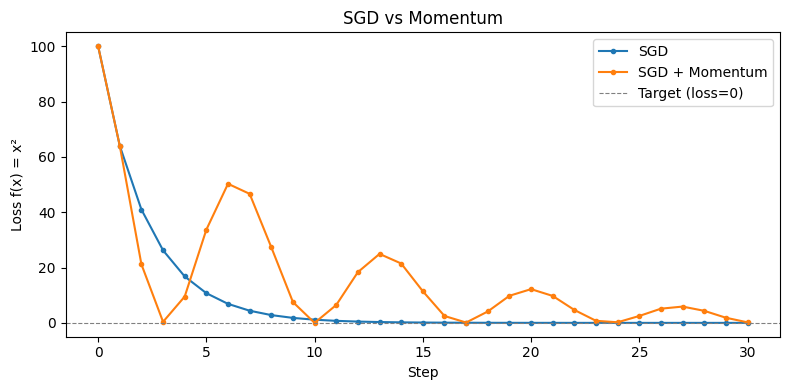

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def loss(x): return x**2
def grad(x): return 2*x

steps = 30
lr = 0.1
gamma = 0.9

# --- SGD ---
x_sgd = 10.0
sgd_path = [x_sgd]
for _ in range(steps):
    gradient = grad(x_sgd)
    ## FILL IN FOR x_sgd
    x_sgd = x_sgd - lr * gradient
    sgd_path.append(x_sgd)

# --- SGD with Momentum ---
x_mom = 10.0
v = 0.0
mom_path = [x_mom]
for _ in range(steps):
    gradient = grad(x_mom)
    ## FILL IN THE MOMENTUM FORMULA
    v = gamma * v + lr * gradient
    x_mom -= v
    mom_path.append(x_mom)

# --- Plot ---
plt.figure(figsize=(8, 4))
plt.plot([loss(x) for x in sgd_path], label="SGD", marker="o", markersize=3)
plt.plot([loss(x) for x in mom_path], label="SGD + Momentum", marker="o", markersize=3)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8, label="Target (loss=0)")
plt.xlabel("Step")
plt.ylabel("Loss f(x) = x²")
plt.title("SGD vs Momentum")
plt.legend()
plt.tight_layout()
plt.show()

Write your observations:

>What is the effect of momentum? What happens as you vary gamma?




observations:
Momentum helps the optimizer to maintain a velocity vector that accumulates the gradients over time this allows the optimizer to continue moving in the same direction even if it encounters small local minima or noisy gradients effectively smoothing the optimization path and accelerating convergence as you vary gamma you will see that higher values of gamma (closer to 1) will result in more momentum being retained from previous updates which can help the optimizer to roll over small local minima but if gamma is too high it may cause the optimizer to overshoot the minimum and diverge on the other hand lower values of gamma (closer to 0) will result in less momentum being retained and the optimizer will behave more like standard SGD which may be slower to converge but less likely to overshoot the minimum.